# CHI-Bench Provider Workflow Analysis

Analysis of the 25 provider-side prior authorization workflows in CHI-Bench.

## Dataset Scope

This analysis uses `analysis/data/provider_task_metadata.csv`, created from task-level metadata only. Hidden evaluation artifacts such as solutions, tests, expectations, and rubrics are intentionally excluded.

In [6]:
import csv
import collections

DATA_PATH = "../data/provider_task_metadata.csv"

with open(DATA_PATH, encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

len(rows)

25

In [7]:
conditions = [r["condition"] for r in rows]
policies = [int(r["policy_count"]) for r in rows]
fixtures = [int(r["fixture_count"]) for r in rows]

print("Provider workflows:", len(rows))
print("Distinct conditions:", len(set(conditions)))
print("Total fixture files:", sum(fixtures))
print("Total policy references:", sum(policies))
print("Average fixtures/workflow:", round(sum(fixtures)/len(rows), 2))
print("Average policies/workflow:", round(sum(policies)/len(rows), 2))
print("Policy range:", min(policies), "to", max(policies))

Provider workflows: 25
Distinct conditions: 21
Total fixture files: 324
Total policy references: 199
Average fixtures/workflow: 12.96
Average policies/workflow: 7.96
Policy range: 6 to 10


In [8]:
condition_counts = collections.Counter(conditions)
print("Repeated conditions:")
for condition, count in condition_counts.items():
    if count > 1:
        print(f"- {condition}: {count}")

Repeated conditions:
- Obstructive sleep apnea: 2
- Headache: 2
- Complete rotator cuff tear or rupture of right shoulder: 2
- Rheumatoid arthritis: 2


In [9]:
policy_distribution = collections.Counter(policies)
print("Policy complexity distribution:")
for policy_count in sorted(policy_distribution):
    print(f"{policy_count} policies: {policy_distribution[policy_count]} workflows")

Policy complexity distribution:
6 policies: 4 workflows
7 policies: 4 workflows
8 policies: 9 workflows
9 policies: 5 workflows
10 policies: 3 workflows


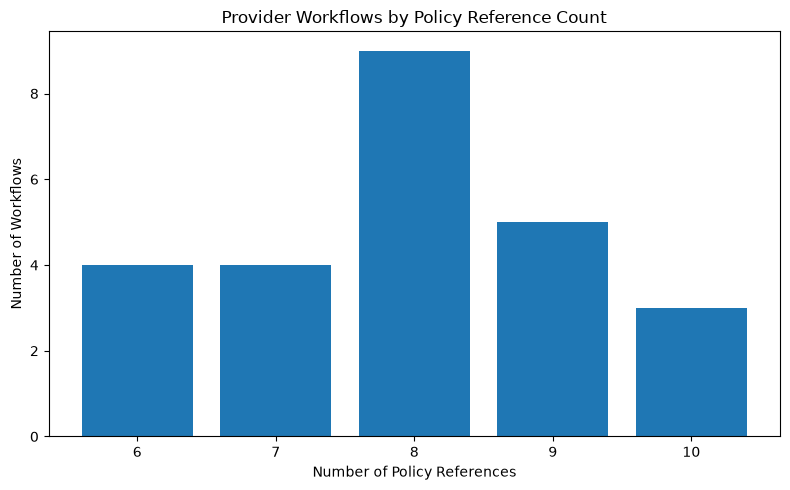

In [11]:
import matplotlib.pyplot as plt

policy_distribution = {
    6: 4,
    7: 4,
    8: 9,
    9: 5,
    10: 3
}

plt.figure(figsize=(8, 5))
plt.bar(
    [str(k) for k in policy_distribution.keys()],
    policy_distribution.values()
)

plt.title("Provider Workflows by Policy Reference Count")
plt.xlabel("Number of Policy References")
plt.ylabel("Number of Workflows")
plt.tight_layout()

plt.savefig("../figures/provider_policy_complexity.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Observation

The provider benchmark contains 25 workflows spanning 21 distinct condition titles. Each workflow references 6–10 policy files, with 68% of workflows having at least 8 policy references. This indicates a multi-source policy and documentation environment rather than a single-rule lookup task.